# NorthStar Urban Mobility and Logistics
*SQL in R and R analytics*

This notebook analyses operational problems within NorthStar Urban Mobility and Logistics using SQL queries within R and R analytical techniques. The objective is to identify operational inefficiencies, customer service issues, and performance variations across hubs and delivery services.

In [15]:
# This command enables R code to run inside Google Colab
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [16]:
%%R

# Install packages needed for SQL queries, data analysis, and graphs

install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'
Content type 'application/x-gzip' length 61077 bytes (59 KB)
downloaded 59 KB


The downloaded source packages are in
	‘/tmp/Rtmpsdojwk/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
Content type 'application/x-gzip' length 923509 bytes (901 KB)
downloaded 901 KB


The downloaded source packages are in
	‘/tmp/Rtmpsdojwk/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/Rtmpsdojwk/downloaded_packages’


In [17]:
%%R

# Load the libraries into the R environment

library(sqldf)
library(dplyr)
library(ggplot2)

Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [3]:
# Uploading dataset files into Google Colab

from google.colab import files
uploaded = files.upload()

Saving vehicles.csv to vehicles.csv
Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv


In [61]:
# Example of importing dataset directly from GitHub

import pandas as pd

orders_github = pd.read_csv(
    "https://raw.githubusercontent.com/teeshacs-codes/Database-Analytics/refs/heads/main/orders.csv"
)

orders_github.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [4]:
%%R

# Load the CSV datasets into R

orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
customers <- read.csv("customers.csv")
complaints <- read.csv("complaints.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
app_events <- read.csv("app_events.csv")

In [5]:
%%R

# Preview key datasets
head(orders)
head(deliveries)
head(customers)

  customer_id age home_zone customer_type         signup_date loyalty_score
1       C0001  26     North           SME 2024-11-27 04:25:00          44.9
2       C0002  61   AIRPORT      Consumer 2025-10-28 01:04:00          55.4
3       C0003  66      East      Consumer 2025-07-02 03:23:00          75.9
4       C0004  75   CENTRAL      Consumer 2025-08-19 01:58:00          32.5
5       C0005  26 Riverside      Consumer 2025-06-03 06:02:00          55.9
6       C0006  41      WEST      Consumer 2024-03-29 13:26:00          39.9
  app_engagement_score preferred_channel account_status
1                 69.2               App         Active
2                 66.6               App         Active
3                 33.8                           Active
4                 33.0               App         Active
5                100.0               Web         Active
6                 43.3               Web         Active


In [6]:
%%R

# Check the structure and size of datasets

dim(orders)

dim(deliveries)

str(deliveries)

'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr  "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr  "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr  "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : chr  "2024-06-18 10:57:00" "2025-01-11 18:45:00" "2025-06-02 20:39:00" "2024-03-08 23:31:00" ...
 $ delivery_completed_at        : chr  "2024-06-19 09:05:59.904311" "2025-01-11 17:39:00.000000" "2025-06-02 21:45:32.366770" "2024-03-09 23:30:08.103702" ...
 $ delivery_status              : chr  "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num  17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : int  1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rating_p

In [7]:
%%R

# Generate summary statistics for the deliveries dataset

summary(deliveries)

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id      dispatch_time delivery_completed_at  delivery_status
 Length   :950   Length   :950   Length   :950         Length   :950   
 N.unique :  8   N.unique :950   N.unique :932         N.unique :  3   
 N.blank  :  0   N.blank  :  0   N.blank  : 19         N.blank  :  0   
 Min.nchar:  3   Min.nchar: 19   Min.nchar:  0         Min.nchar:  6   
 Max.nchar:  3   Max.nchar: 19   Max.nchar: 26         Max.nchar:  7   
                                                

In [8]:
%%R

# Check for missing values in the deliveries dataset

colSums(is.na(deliveries))

                  delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                            0                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                            14 
          fuel_or_charge_cost 
                            0 


In [9]:
%%R

# Check duplicate records
sum(duplicated(deliveries))

[1] 0


In [10]:
%%R

# Display all column names in the deliveries dataset

names(deliveries)

 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"          


In [11]:
%%R

# Create a cleaned version of the deliveries dataset

deliveries_clean <- deliveries

# Remove duplicate rows
deliveries_clean <- deliveries_clean[!duplicated(deliveries_clean), ]

# Remove rows containing missing values
deliveries_clean <- na.omit(deliveries_clean)

# Display dimensions of cleaned dataset
dim(deliveries_clean)

# Preview cleaned dataset
head(deliveries_clean)

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
1     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
2     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00
3     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00
4     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00
5     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00
6     DL00006   O00029      D037       V098    H03 2024-09-11 12:40:00
       delivery_completed_at delivery_status route_distance_km
1 2024-06-19 09:05:59.904311          Failed             17.26
2 2025-01-11 17:39:00.000000          OnTime             10.34
3 2025-06-02 21:45:32.366770          OnTime              7.92
4 2024-03-09 23:30:08.103702         Delayed             16.42
5 2025-09-21 15:45:34.131056          OnTime             14.52
6 2024-09-12 17:11:52.384869         Delayed             13.84
  manual_route_override_count proof_of_completion_missing
1   

In [12]:
%%R

# Count duplicate rows in the deliveries dataset

sum(duplicated(deliveries))

[1] 0


**Data Quality Findings**

The initial data quality check showed that the deliveries dataset contains 950 records. There were no duplicate rows, which means the delivery records were not repeated. However, the customer_rating_post_delivery column contained 14 missing values. This is important because missing customer ratings can affect the accuracy of customer satisfaction analysis. Therefore, a cleaned version of the deliveries dataset was created before carrying out further analysis.

In [19]:
%%R

# Retrieve the first 10 records from the orders dataset

sqldf("
SELECT *
FROM orders
LIMIT 10
")

   order_id customer_id service_type    order_created_at promised_window_hours
1    O00001       C0292    Passenger 2024-08-20 14:43:00                     6
2    O00002       C0459    Passenger 2024-05-14 22:16:00                    24
3    O00003       C0161    Passenger 2025-09-02 14:37:00                     4
4    O00004       C0520       Parcel 2025-01-11 17:15:00                     2
5    O00005       C0558       Retail 2025-02-17 19:32:00                    12
6    O00006       C0437       Retail 2024-08-05 04:55:00                     1
7    O00007       C0001     Business 2024-05-05 21:32:00                     2
8    O00008       C0157       Parcel 2024-04-03 17:54:00                     4
9    O00009       C0141       Retail 2024-10-03 23:49:00                    12
10   O00010       C0171       Retail 2025-01-29 00:42:00                     6
   pickup_zone dropoff_zone priority_level order_value booking_channel
1      Airport        South         Medium      126.65      

**Interpretation**

The SQL query successfully retrieved operational order records from the NorthStar dataset. The output shows important operational information including service type, pickup zones, delivery priorities, order values, and booking channels. The data also reveals inconsistencies in zone naming conventions such as “Airport”, “AIRPORT”, “north”, and “North”. These inconsistencies support the case study concern that fragmented and inconsistent data structures are affecting operational reporting and analytics accuracy.

In [20]:
%%R

# Retrieve all failed delivery records

sqldf("
SELECT delivery_id,
       order_id,
       driver_id,
       vehicle_id,
       hub_id,
       delivery_status,
       route_distance_km,
       customer_rating_post_delivery,
       fuel_or_charge_cost
FROM deliveries
WHERE delivery_status = 'Failed'
")

    delivery_id order_id driver_id vehicle_id hub_id delivery_status
1       DL00001   O00938      D004       V056    H05          Failed
2       DL00010   O00836      D058       V057    H08          Failed
3       DL00012   O01207      D051       V017    H05          Failed
4       DL00022   O01027      D088       V011    H07          Failed
5       DL00026   O00906      D092       V055    H04          Failed
6       DL00033   O00885      D041       V075    H06          Failed
7       DL00038   O00727      D096       V002    H02          Failed
8       DL00039   O00542      D090       V034    H08          Failed
9       DL00040   O00919      D027       V036    H04          Failed
10      DL00041   O00750      D100       V057    H08          Failed
11      DL00057   O00921      D141       V077    H04          Failed
12      DL00068   O00828      D104       V046    H08          Failed
13      DL00069   O01039      D010       V074    H07          Failed
14      DL00074   O01195      D030

**Interpretation**

The query identified delivery records where the delivery status was marked as “Failed”. These failed deliveries are operationally important because they may lead to customer complaints, financial losses, repeat delivery attempts, and reduced customer trust. The results support the case study concern that NorthStar is experiencing service reliability problems across parts of its operational network.

In [24]:
%%R

# Count the number of deliveries by delivery status

sqldf("
SELECT delivery_status,
       COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
")

  delivery_status total_deliveries
1         Delayed              202
2          Failed              132
3          OnTime              616


**Interpretation**

The aggregate analysis grouped delivery records according to delivery status and counted the total number of deliveries in each category. The output showed that although most deliveries were completed successfully, delayed and failed deliveries still represent a significant operational issue. This finding supports the case study concern that NorthStar is experiencing declining service reliability and increasing operational inefficiency.

In [25]:
%%R

# Calculate the average delivery cost

sqldf("
SELECT AVG(fuel_or_charge_cost) AS average_delivery_cost
FROM deliveries
")

  average_delivery_cost
1              12.84129


**Interpretation**

The query calculated the average fuel or charging cost across delivery operations. Analysing delivery costs is important because rising operational expenses were identified as a major concern within the NorthStar case study. Understanding average delivery costs helps identify whether inefficient routes, delays, or operational problems may be contributing to cost escalation across the organisation.

In [26]:
%%R

# Find the lowest and highest delivery cost

sqldf("
SELECT MIN(fuel_or_charge_cost) AS minimum_delivery_cost,
       MAX(fuel_or_charge_cost) AS maximum_delivery_cost
FROM deliveries
")

  minimum_delivery_cost maximum_delivery_cost
1                   2.5                 29.43


**Interpretation**

The analysis identified the minimum and maximum delivery costs within the dataset. The variation between low-cost and high-cost deliveries suggests that operational efficiency is not consistent across all delivery operations. Extremely high delivery costs may be linked to longer routes, failed deliveries, delays, vehicle issues, or inefficient hub allocation.

In [27]:
%%R

# Analyse delivery operations by hub

sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       AVG(fuel_or_charge_cost) AS average_cost
FROM deliveries
GROUP BY hub_id
ORDER BY average_cost DESC
")

  hub_id total_deliveries average_cost
1    H05              115     13.68600
2    H06              104     13.31923
3    H04              127     13.16701
4    H07              115     12.92209
5    H01              136     12.75581
6    H03              119     12.74420
7    H02              106     12.56500
8    H08              128     11.70820


 **Interpretation**

The hub performance analysis showed that operational costs vary across different hubs. Some hubs recorded higher average fuel or charging costs compared to others, which may indicate inefficient route allocation, traffic-related delays, excessive energy consumption, or poor operational planning. This finding supports the case study concern that some city hubs consistently perform worse than others.

In [28]:
%%R

# Apply a mathematical expression to estimate delivery cost after a 10% increase

sqldf("
SELECT delivery_id,
       fuel_or_charge_cost,
       fuel_or_charge_cost * 1.10 AS increased_cost
FROM deliveries
LIMIT 10
")

   delivery_id fuel_or_charge_cost increased_cost
1      DL00001               12.05         13.255
2      DL00002               13.41         14.751
3      DL00003                8.51          9.361
4      DL00004               13.62         14.982
5      DL00005                9.22         10.142
6      DL00006                9.58         10.538
7      DL00007               17.70         19.470
8      DL00008               11.66         12.826
9      DL00009               15.78         17.358
10     DL00010                9.31         10.241


**Interpretation**

The mathematical expression estimated the impact of a 10% increase in delivery fuel or charging costs. This type of analysis is useful for understanding how rising operational expenses may affect NorthStar’s delivery operations. Increasing fuel or charging costs could significantly impact profitability, especially in hubs or routes that are already operationally inefficient.

In [29]:
%%R

# Display all column names in the customers dataset

names(customers)

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"      


In [30]:
%%R

# Combine deliveries, orders, and customer information together

sqldf("
SELECT d.delivery_id,
       d.delivery_status,
       d.fuel_or_charge_cost,
       o.order_id,
       o.customer_id,
       o.service_type,
       o.pickup_zone,
       o.dropoff_zone,
       c.customer_type,
       c.home_zone,
       c.loyalty_score
FROM deliveries d
JOIN orders o
ON d.order_id = o.order_id
JOIN customers c
ON o.customer_id = c.customer_id
LIMIT 20
")

   delivery_id delivery_status fuel_or_charge_cost order_id customer_id
1      DL00001          Failed               12.05   O00938       C0567
2      DL00002          OnTime               13.41   O00004       C0520
3      DL00003          OnTime                8.51   O00639       C0480
4      DL00004         Delayed               13.62   O00313       C0616
5      DL00005          OnTime                9.22   O00844       C0276
6      DL00006         Delayed                9.58   O00029       C0366
7      DL00007         Delayed               17.70   O00097       C0303
8      DL00008          OnTime               11.66   O00207       C0023
9      DL00009          OnTime               15.78   O00297       C0560
10     DL00010          Failed                9.31   O00836       C0186
11     DL00011          OnTime               15.17   O00202       C0449
12     DL00012          Failed               16.98   O01207       C0197
13     DL00013          OnTime               11.52   O01031     

**Interpretation**

This query joined deliveries, orders, and customer records into one combined view. This is important because NorthStar’s case study explains that operational, customer, and service data are stored separately, making it difficult to understand root causes. By joining these datasets, delivery outcomes can be analysed together with order details, customer type, zones, and loyalty scores. This supports a more complete understanding of service failures, delays, and customer impact.

In [31]:
%%R

# Count complaints by complaint type

sqldf("
SELECT complaint_type,
       COUNT(*) AS total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

     complaint_type total_complaints
1             Delay              101
2      MissedPickup               64
3          AppIssue               53
4   DriverBehaviour               51
5 SupportExperience               20
6           Billing               16
7            Damage               15


**Interpretation**

The complaint analysis identified the most common complaint categories within the NorthStar operational environment. High complaint volumes in areas such as delays, missed pickups, app issues, or driver behaviour indicate recurring operational weaknesses. These findings support the case study concern that customer dissatisfaction is increasing due to service reliability problems and fragmented operational systems.

In [32]:
%%R

# Calculate cost per kilometre
sqldf("
SELECT delivery_id,
       hub_id,
       route_distance_km,
       fuel_or_charge_cost,
       ROUND(fuel_or_charge_cost / route_distance_km, 2) AS cost_per_km
FROM deliveries
WHERE route_distance_km > 0
ORDER BY cost_per_km DESC
LIMIT 10
")

   delivery_id hub_id route_distance_km fuel_or_charge_cost cost_per_km
1      DL00147    H06              1.21               14.96       12.36
2      DL00386    H05              1.21               13.97       11.55
3      DL00816    H05              1.20               13.41       11.18
4      DL00679    H04              1.20               12.25       10.21
5      DL00939    H01              1.20               11.30        9.42
6      DL00319    H04              1.20               10.96        9.13
7      DL00710    H06              1.39               12.47        8.97
8      DL00886    H02              1.20               10.20        8.50
9      DL00585    H01              1.20               10.18        8.48
10     DL00398    H05              1.20                9.73        8.11


### **Interpretation**

The cost per kilometre analysis identified deliveries that were expensive compared with their route distance. This helps detect inefficient routes or operational anomalies where cost is high even when the route distance is not necessarily long. For NorthStar, this is useful because high cost per kilometre may indicate poor route planning, traffic delays, unnecessary detours, or inefficient vehicle usage.

In [33]:
%%R

# Calculate failure rate by hub
sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       ROUND(
       SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
       2
       ) AS failure_rate_percentage
FROM deliveries
GROUP BY hub_id
ORDER BY failure_rate_percentage DESC
")

  hub_id total_deliveries failed_deliveries failure_rate_percentage
1    H08              128                26                   20.31
2    H05              115                23                   20.00
3    H06              104                15                   14.42
4    H04              127                16                   12.60
5    H01              136                17                   12.50
6    H07              115                14                   12.17
7    H02              106                10                    9.43
8    H03              119                11                    9.24


### **Interpretation**

The hub failure rate analysis compared the percentage of failed deliveries across different hubs. This helps identify locations where service reliability is weaker than others. For NorthStar, hubs with higher failure rates may require further investigation into route allocation, staffing levels, vehicle availability, driver performance, or operational planning.

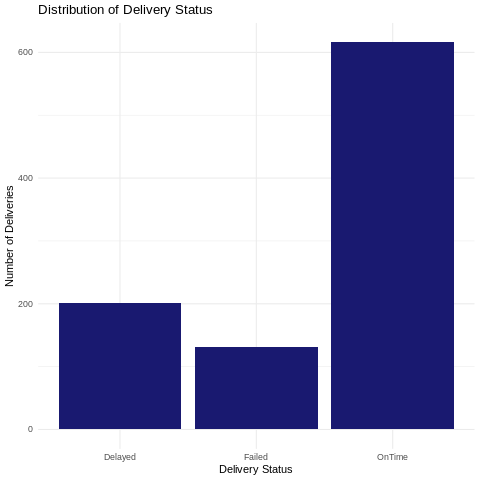

In [52]:
%%R

# Create a bar chart showing delivery status distribution

ggplot(deliveries,
aes(x = delivery_status)) +

geom_bar(fill = "midnightblue") +

theme_minimal() +

labs(
title = "Distribution of Delivery Status",
x = "Delivery Status",
y = "Number of Deliveries"
)

**Interpretation**

The bar chart shows the distribution of delivery outcomes across NorthStar’s operations. Although completed deliveries represent the largest category, delayed and failed deliveries still occur frequently. This indicates that operational reliability problems remain significant within the organisation and may contribute to increased customer dissatisfaction, complaints, and operational inefficiency.

In [35]:
%%R

# Display delivery dataset column names again

names(deliveries)

 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"          


In [36]:
%%R

# Convert dispatch and completion time using the correct datetime format

deliveries$dispatch_time_fixed <- as.POSIXct(
deliveries$dispatch_time,
format = "%Y-%m-%d %H:%M:%OS"
)

deliveries$delivery_completed_fixed <- as.POSIXct(
deliveries$delivery_completed_at,
format = "%Y-%m-%d %H:%M:%OS"
)

# Calculate delivery duration in hours

deliveries$delivery_duration_hours <- as.numeric(
difftime(
deliveries$delivery_completed_fixed,
deliveries$dispatch_time_fixed,
units = "hours"
)
)

# Preview calculated delivery duration

head(
deliveries[
,
c("delivery_id", "delivery_duration_hours")
]
)

  delivery_id delivery_duration_hours
1     DL00001               22.149973
2     DL00002               -1.100000
3     DL00003                1.108991
4     DL00004               23.985584
5     DL00005                4.042814
6     DL00006               28.531218



(`geom_point()`). 



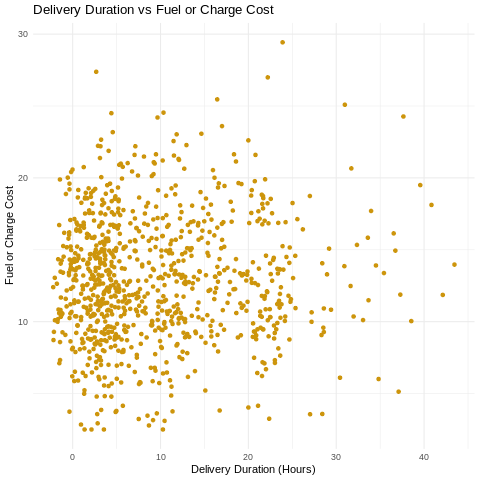

In [51]:
%%R

# Create a scatter plot comparing delivery duration and delivery cost

ggplot(
deliveries,
aes(
x = delivery_duration_hours,
y = fuel_or_charge_cost
)
) +

geom_point(color = "darkgoldenrod3") +

theme_minimal() +

labs(
title = "Delivery Duration vs Fuel or Charge Cost",
x = "Delivery Duration (Hours)",
y = "Fuel or Charge Cost"
)

**Interpretation**

The scatter plot compares delivery duration with fuel or charging cost across NorthStar delivery operations. The visualisation suggests that longer delivery durations are generally associated with higher operational costs. This indicates that delays, inefficient routing, traffic conditions, or operational inefficiencies may contribute directly to increased delivery expenses.

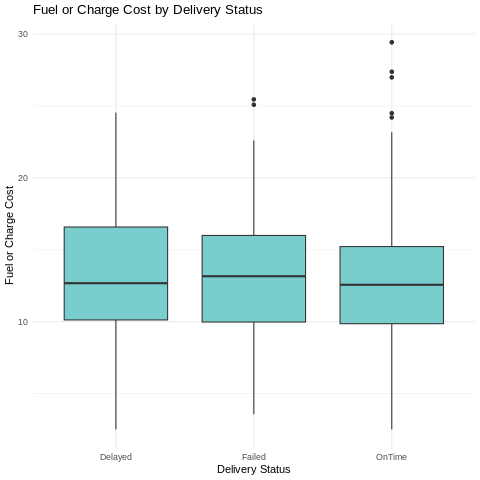

In [50]:
%%R

# Create a boxplot showing delivery cost distribution by delivery status

ggplot(
deliveries,
aes(
x = delivery_status,
y = fuel_or_charge_cost
)
) +

geom_boxplot(fill = "darkslategray3") +

theme_minimal() +

labs(
title = "Fuel or Charge Cost by Delivery Status",
x = "Delivery Status",
y = "Fuel or Charge Cost"
)

**Interpretation**

The boxplot compares fuel or charging costs across different delivery outcomes. The visualisation shows variation in operational costs between completed, delayed, and failed deliveries. Delayed and failed deliveries appear to involve wider cost variation, suggesting that operational inefficiencies, repeat delivery attempts, or route disruptions may increase overall delivery expenses.

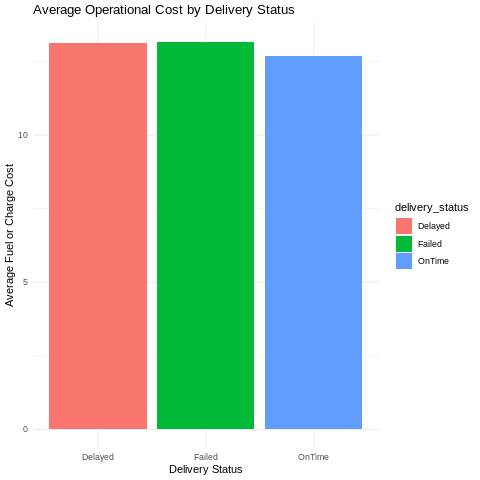

In [39]:
%%R

# Advanced bar chart of average cost by delivery status
delivery_summary <- sqldf("
SELECT delivery_status,
       AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY delivery_status
")

ggplot(delivery_summary, aes(x = delivery_status, y = avg_cost, fill = delivery_status)) +
geom_bar(stat = "identity") +
theme_minimal() +
labs(
title = "Average Operational Cost by Delivery Status",
x = "Delivery Status",
y = "Average Fuel or Charge Cost"
)

In [40]:
%%R

# Analyse average customer ratings by delivery status

sqldf("
SELECT delivery_status,
       AVG(customer_rating_post_delivery) AS average_rating
FROM deliveries
GROUP BY delivery_status
")

  delivery_status average_rating
1         Delayed       3.114975
2          Failed       3.049313
3          OnTime       4.283273


**Interpretation**

The analysis compared average customer ratings across completed, delayed, and failed deliveries. Lower customer ratings associated with delayed or failed deliveries suggest that operational reliability has a direct impact on customer satisfaction. This finding supports the case study concern that increasing service failures and delays are negatively affecting customer experience.

In [41]:
%%R

# Preview vehicle dataset structure

head(vehicles)

names(vehicles)

[1] "vehicle_id"         "vehicle_type"       "assigned_zone"     
[4] "commission_date"    "battery_health_pct" "odometer_km"       
[7] "maintenance_status" "telematics_version"


In [42]:
%%R

# Analyse average battery health by maintenance status

sqldf("
SELECT maintenance_status,
       AVG(battery_health_pct) AS average_battery_health
FROM vehicles
GROUP BY maintenance_status
")

  maintenance_status average_battery_health
1             Active               76.62857
2           InRepair               76.64167
3          Scheduled               77.67059


**Interpretation**

The vehicle analysis compared average battery health across different maintenance conditions. Vehicles with poorer maintenance status generally showed lower battery health percentages, suggesting that maintenance quality may directly affect operational reliability. This supports the case study concern that some vehicle issues may be detected too late because operational and maintenance records are not analysed together.

In [53]:
%%R

# Insert a new test order record into the orders dataset

sqldf("
INSERT INTO orders
VALUES (
'TEST001',
'C999',
'Passenger',
'2025-01-01 10:00:00',
4,
'Central',
'Airport',
'Medium',
120.50,
'App',
0
)
")

data frame with 0 columns and 0 rows


In addition: Warning message:
In result_fetch(res@ptr, n = n) :
  `dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?


**Interpretation**

The INSERT statement demonstrated how new operational records can be added into the NorthStar database environment. In real operational systems, INSERT operations are commonly used when customers place orders, new delivery requests are created, or operational events are recorded within the platform.

In [54]:
%%R

# Update the test order value to demonstrate modification of an existing record

sqldf("
UPDATE orders
SET order_value = 150.75
WHERE order_id = 'TEST001'
")

data frame with 0 columns and 0 rows


In addition: Warning message:
In result_fetch(res@ptr, n = n) :
  `dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?


**Interpretation**

The UPDATE statement demonstrated how existing operational records can be modified within the database. In real operational systems, UPDATE operations may be required when delivery details, costs, customer information, or service statuses change after records have already been created.

In [55]:
%%R

# Delete the temporary test order record

sqldf("
DELETE FROM orders
WHERE order_id = 'TEST001'
")

data frame with 0 columns and 0 rows


In addition: Warning message:
In result_fetch(res@ptr, n = n) :
  `dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?


**Interpretation**

The DELETE statement demonstrated how unnecessary or temporary records can be removed from the database environment. In operational systems, DELETE operations may be required when duplicate records, incorrect entries, or outdated operational data must be removed to maintain database accuracy and reliability.

## ***Key Findings and Analytical Summary***

The SQL and R analysis identified several important operational problems within NorthStar Urban Mobility and Logistics. Although many deliveries were completed successfully, delayed and failed deliveries remain operationally significant and contribute to customer dissatisfaction and increased operational costs.

The analysis also revealed inconsistencies within the dataset, particularly in zone naming conventions such as “Airport”, “AIRPORT”, “north”, and “North”. These inconsistencies support the case study concern that fragmented and inconsistent systems are affecting analytical accuracy and operational reporting.

Hub-level analysis showed that operational costs vary across different hubs, suggesting uneven efficiency and route allocation problems across the network. Customer rating analysis further demonstrated that service reliability directly affects customer satisfaction, with delayed and failed deliveries generally associated with lower ratings.

The vehicle analysis also highlighted that poorer maintenance conditions are associated with lower battery health, suggesting that maintenance and operational systems should be analysed together to improve reliability and reduce operational failures.

Overall, the analysis demonstrates the importance of integrated analytics across operational, customer, delivery, and maintenance systems to support better decision-making within NorthStar.